# 7.3 — Phân tích Pilot

**Vai trò:** MS (Metric & Statistics)
**Input:** `results/pilot_llm_output.csv` (LR, §7.2) + `data/pilot_ground_truth.csv` (DG, §7.1)
**Output:** metric pilot (Cohen's Kappa), histogram phân phối, xác nhận statistical test cho Tuần 8.

Mọi số liệu trong notebook này được tính trực tiếp từ 2 file CSV gốc — không có giá trị nào được nhập tay.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score, precision_score, recall_score

pd.set_option('display.max_colwidth', 80)


##  Load dữ liệu thô và kiểm tra trực tiếp

In toàn bộ 2 cột khóa từ cả 2 file để đối chiếu được với file CSV gốc.


In [2]:

llm = pd.read_csv('../results/pilot_llm_output.csv', encoding='utf-8-sig')
gt  = pd.read_csv('../data/pilot_ground_truth.csv', encoding='utf-8-sig')

print(f"pilot_llm_output.csv    : {len(llm)} dòng, cột = {list(llm.columns)}")
print(f"pilot_ground_truth.csv  : {len(gt)} dòng, cột = {list(gt.columns)}")


pilot_llm_output.csv    : 26 dòng, cột = ['issue_key', 's2r_label', 'reason', 'status', 'model', 'prompt_version', 'input_tokens', 'cached_input_tokens', 'output_tokens', 'total_tokens', 'cost_usd', 'timestamp', 'raw_response']
pilot_ground_truth.csv  : 26 dòng, cột = ['BUG-ID', 'S2R Label', 'S2R Irrep Category', 'Reason', 'OB Category', 'OB Label', 'Reason.1', 'EB Category', 'EB Label', 'Reason.2', 'Unnamed: 10', 'Unnamed: 11']


In [3]:

# In toàn bộ nhãn LLM để đối chiếu trực tiếp với file CSV gốc
llm[['issue_key', 's2r_label']]


,issue_key,s2r_label
0,MC-300962,Executable
1,MC-299218,Executable
2,MC-301018,Executable
3,MC-300634,Executable
4,MC-299909,Executable
5,MC-300861,Executable
6,MC-300776,Executable
7,MC-300107,Executable
8,MC-300598,Executable
9,MC-300539,Executable


In [4]:

# In toàn bộ nhãn ground truth để đối chiếu trực tiếp với file CSV gốc
gt[['BUG-ID', 'S2R Label']]


,BUG-ID,S2R Label
0,MC-300962 Improved,Executable
1,MC-299218 Improved,Non-Executable
2,MC-301018 Improved,Executable
3,MC-300634 Improved,Non-Executable
4,MC-299909 Improved,Executable
5,MC-300861 Improved,Executable
6,MC-300776 Improved,Executable
7,MC-300107 Improved,Executable
8,MC-300598 Improved,Non-Executable
9,MC-300539 Improved,Executable


##  Merge dữ liệu

`BUG-ID` trong ground truth có hậu tố `" Improved"` — chuẩn hóa về cùng định dạng với `issue_key` trước khi merge.


In [5]:

gt['issue_key'] = gt['BUG-ID'].str.replace(' Improved', '', regex=False).str.strip()

merged = llm.merge(gt, on='issue_key', how='outer', indicator=True)
mismatch = merged[merged['_merge'] != 'both']
print(f"Số dòng KHÔNG khớp được giữa 2 file: {len(mismatch)}")
mismatch[['issue_key', '_merge']]


Số dòng KHÔNG khớp được giữa 2 file: 0


,issue_key,_merge


In [6]:

assert len(mismatch) == 0, "Có issue_key không khớp — dừng lại, báo LR/DG."
merged = merged.drop(columns=['_merge'])
merged = merged.rename(columns={'s2r_label': 'llm_label', 'S2R Label': 'human_label'})
merged[['issue_key', 'llm_label', 'human_label']]


,issue_key,llm_label,human_label
0,MC-299218,Executable,Non-Executable
1,MC-299909,Executable,Executable
2,MC-300031,Executable,Executable
3,MC-300033,Executable,Executable
4,MC-300107,Executable,Executable
5,MC-300409,Executable,Non-Executable
6,MC-300420,Executable,Executable
7,MC-300539,Executable,Executable
8,MC-300562,Executable,Executable
9,MC-300598,Executable,Non-Executable


##  Confusion matrix (đếm trực tiếp, không qua hàm thư viện)

Đếm thủ công 4 ô để bất kỳ ai review cũng verify được bằng mắt, sau đó đối chiếu với `sklearn.metrics.confusion_matrix`.


In [7]:

y_true = merged['human_label']
y_pred = merged['llm_label']
n = len(merged)

tp = ((y_true=='Non-Executable') & (y_pred=='Non-Executable')).sum()
fn = ((y_true=='Non-Executable') & (y_pred=='Executable')).sum()
fp = ((y_true=='Executable') & (y_pred=='Non-Executable')).sum()
tn = ((y_true=='Executable') & (y_pred=='Executable')).sum()

print("Đếm tay:")
print(f"  Human=Non-Executable, LLM=Non-Executable : {tp}")
print(f"  Human=Non-Executable, LLM=Executable     : {fn}")
print(f"  Human=Executable,     LLM=Non-Executable : {fp}")
print(f"  Human=Executable,     LLM=Executable     : {tn}")
print(f"  Tổng: {tp+fn+fp+tn} (phải = N = {n})")

labels = ['Executable', 'Non-Executable']
cm_sklearn = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm_sklearn, index=[f"human: {l}" for l in labels], columns=[f"llm: {l}" for l in labels])
print("\nĐối chiếu với sklearn.metrics.confusion_matrix:")
cm_df


Đếm tay:
  Human=Non-Executable, LLM=Non-Executable : 0
  Human=Non-Executable, LLM=Executable     : 7
  Human=Executable,     LLM=Non-Executable : 0
  Human=Executable,     LLM=Executable     : 19
  Tổng: 26 (phải = N = 26)

Đối chiếu với sklearn.metrics.confusion_matrix:


,llm: Executable,llm: Non-Executable
human: Executable,19,0
human: Non-Executable,7,0


##  Cohen's Kappa 

Công thức: κ = (p_o − p_e) / (1 − p_e)
- p_o = tỷ lệ đồng thuận quan sát được (observed agreement)
- p_e = tỷ lệ đồng thuận kỳ vọng do ngẫu nhiên (expected agreement by chance)


In [8]:

po = (tp + tn) / n
p_human_nonexec = (y_true == 'Non-Executable').mean()
p_llm_nonexec = (y_pred == 'Non-Executable').mean()
pe = p_human_nonexec * p_llm_nonexec + (1 - p_human_nonexec) * (1 - p_llm_nonexec)
kappa_manual = (po - pe) / (1 - pe) if pe != 1 else float('nan')

kappa_sklearn = cohen_kappa_score(y_true, y_pred, labels=labels)

print(f"Observed agreement (po) = {po:.4f}")
print(f"Expected agreement (pe) = {pe:.4f}")
print(f"Cohen's Kappa (tính tay theo công thức) = {kappa_manual:.4f}")
print(f"Cohen's Kappa (sklearn, đối chiếu)       = {kappa_sklearn:.4f}")
assert abs(kappa_manual - kappa_sklearn) < 1e-9, "Hai cách tính KHÔNG khớp — dừng lại kiểm tra."
print("\n=> Hai cách tính khớp nhau tuyệt đối.")


Observed agreement (po) = 0.7308
Expected agreement (pe) = 0.7308
Cohen's Kappa (tính tay theo công thức) = -0.0000
Cohen's Kappa (sklearn, đối chiếu)       = 0.0000

=> Hai cách tính khớp nhau tuyệt đối.


In [9]:

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label='Non-Executable', zero_division=0)
rec = recall_score(y_true, y_pred, pos_label='Non-Executable', zero_division=0)
print(f"Accuracy                   : {acc:.4f}")
print(f"Precision (Non-Executable) : {prec:.4f}")
print(f"Recall (Non-Executable)    : {rec:.4f}")


Accuracy                   : 0.7308
Precision (Non-Executable) : 0.0000
Recall (Non-Executable)    : 0.0000


In [ ]:

# Bootstrap 95% CI cho Kappa (proposal §6.1)
rng = np.random.default_rng(42)
n_boot = 2000
boot_kappas = []

for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    yt = y_true.values[idx]
    yp = y_pred.values[idx]
    if len(set(yt)) < 2 and len(set(yp)) < 2:
        continue
    boot_kappas.append(cohen_kappa_score(yt, yp, labels=labels))

ci_low, ci_high = np.percentile(boot_kappas, [2.5, 97.5])
print(f"Bootstrap 95% CI cho Kappa: [{ci_low:.4f}, {ci_high:.4f}]  (n_boot={len(boot_kappas)}, seed=42)")


Bootstrap 95% CI cho Kappa: [0.0000, 0.0000]  (n_boot=1999, seed=42)


##  Histogram phân phối

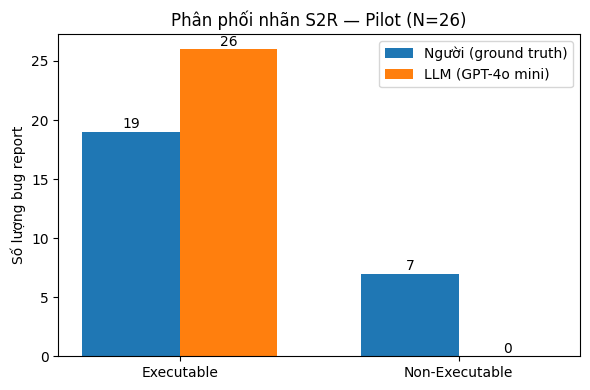

Người:  Executable=19, Non-Executable=7
LLM:    Executable=26, Non-Executable=0


In [11]:

fig, ax = plt.subplots(figsize=(6, 4))
counts_human = y_true.value_counts().reindex(labels, fill_value=0)
counts_llm = y_pred.value_counts().reindex(labels, fill_value=0)

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, counts_human.values, width, label='Người (ground truth)')
ax.bar(x + width/2, counts_llm.values, width, label='LLM (GPT-4o mini)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Số lượng bug report')
ax.set_title(f'Phân phối nhãn S2R — Pilot (N={n})')
ax.legend()
for i, v in enumerate(counts_human.values):
    ax.text(i - width/2, v + 0.3, str(v), ha='center')
for i, v in enumerate(counts_llm.values):
    ax.text(i + width/2, v + 0.3, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f"Người:  Executable={counts_human['Executable']}, Non-Executable={counts_human['Non-Executable']}")
print(f"LLM:    Executable={counts_llm['Executable']}, Non-Executable={counts_llm['Non-Executable']}")


##  Xác nhận lựa chọn statistical test

Proposal §5.1 dự kiến Wilcoxon signed-rank test — giả định điểm dạng số liên tục/ordinal (1–5).
Dữ liệu thực tế: nhãn categorical nhị phân (Executable/Non-Executable) → khác dự kiến trong proposal.


In [12]:

from statsmodels.stats.contingency_tables import mcnemar

result = mcnemar(cm_sklearn, exact=True)
print(f"McNemar's test: statistic = {result.statistic}, p-value = {result.pvalue:.4f}")
print("\nPhân phối như dự kiến trong proposal (numeric 1-5)? False — dữ liệu là categorical nhị phân.")
print("=> Đề xuất: dùng McNemar's test thay Wilcoxon cho Tuần 8. Cần ghi notes.md + báo GV/PL, cân nhắc amendment.")


McNemar's test: statistic = 0.0, p-value = 0.0156

Phân phối như dự kiến trong proposal (numeric 1-5)? False — dữ liệu là categorical nhị phân.
=> Đề xuất: dùng McNemar's test thay Wilcoxon cho Tuần 8. Cần ghi notes.md + báo GV/PL, cân nhắc amendment.


##  Kết luận pilot & gate theo proposal §5.1

In [13]:

print(f"N pilot                    : {n}")
print(f"Cohen's Kappa (κ_LLM pilot): {kappa_manual:.4f}  (95% CI [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Ngưỡng gate proposal §5.1  : κ_LLM pilot >= 0.40")
print(f"Gate pilot                 : {'ĐẠT' if kappa_manual >= 0.40 else 'KHÔNG ĐẠT'}")
print(f"LLM dự đoán toàn bộ là     : {y_pred.value_counts().idxmax()} ({(y_pred==y_pred.value_counts().idxmax()).sum()}/{n} dòng)")


N pilot                    : 26
Cohen's Kappa (κ_LLM pilot): -0.0000  (95% CI [0.0000, 0.0000])
Ngưỡng gate proposal §5.1  : κ_LLM pilot >= 0.40
Gate pilot                 : KHÔNG ĐẠT
LLM dự đoán toàn bộ là     : Executable (26/26 dòng)


**Diễn giải:** κ_LLM pilot < 0.40 → theo gate của proposal §5.1, chiến lược prompt (zero-shot) chưa phù hợp, cần chuyển sang few-shot (k=3) và chạy lại pilot trước khi mở khóa Tuần 8. Nguyên nhân kỹ thuật: LLM dự đoán `Executable` cho toàn bộ 26/26 report, không có variance để phân biệt với ground truth (7/26 report thực tế là `Non-Executable`).


In [14]:

notes_entry = f'''
## [Tuan 7 - Pilot Analysis] {pd.Timestamp.now().isoformat()}

- N pilot: {n}
- Cohen's Kappa (LLM vs human, S2R): {kappa_manual:.4f} (95% CI [{ci_low:.4f}, {ci_high:.4f}]) -- tinh tay va sklearn khop nhau
- Confusion matrix: TP(NonExec/NonExec)={tp}, FN(NonExec human/Exec llm)={fn}, FP(Exec human/NonExec llm)={fp}, TN(Exec/Exec)={tn}
- Gate proposal S5.1: kappa pilot >= 0.40 -> KHONG DAT (kappa = {kappa_manual:.4f})
- Nguyen nhan: LLM du doan "Executable" cho toan bo {n}/{n} report, khong co variance
- Statistical test: Wilcoxon (du kien proposal) KHONG phu hop vi nhan la categorical nhi phan.
  De xuat doi sang McNemar's test cho Tuan 8. Can amendment.
- Quyet dinh: theo dung gate S5.1, KHONG duoc tien hanh full experiment voi config hien tai.
'''

with open('../notes.md', 'a', encoding='utf-8') as f:
    f.write(notes_entry)

print("Đã ghi vào notes.md:")
print(notes_entry)


Đã ghi vào notes.md:

## [Tuan 7 - Pilot Analysis] 2026-07-03T07:10:07.042433

- N pilot: 26
- Cohen's Kappa (LLM vs human, S2R): -0.0000 (95% CI [0.0000, 0.0000]) -- tinh tay va sklearn khop nhau
- Confusion matrix: TP(NonExec/NonExec)=0, FN(NonExec human/Exec llm)=7, FP(Exec human/NonExec llm)=0, TN(Exec/Exec)=19
- Gate proposal S5.1: kappa pilot >= 0.40 -> KHONG DAT (kappa = -0.0000)
- Nguyen nhan: LLM du doan "Executable" cho toan bo 26/26 report, khong co variance
- Statistical test: Wilcoxon (du kien proposal) KHONG phu hop vi nhan la categorical nhi phan.
  De xuat doi sang McNemar's test cho Tuan 8. Can amendment.
- Quyet dinh: theo dung gate S5.1, KHONG duoc tien hanh full experiment voi config hien tai.

